# Heart Disease Prediction

Binary classification on the UCI Heart Disease dataset comparing logistic regression, decision tree, and random forest with hyperparameter tuning.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [13]:
# Load the dataset
df = pd.read_csv('../data/heart.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1025, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Data Exploration

Checking for missing values, class balance, and basic statistics.

In [ ]:
# Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
# Checking class balance - how many patients have heart disease vs not?
print("Target class distribution:")
print(df['target'].value_counts())
print("\nProportion:")
print(df['target'].value_counts(normalize=True))

Target class distribution:
target
1    526
0    499
Name: count, dtype: int64

Proportion:
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [15]:
df.describe() #stats summary of all features

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Visualization

Looking at class balance and how key features relate to heart disease.

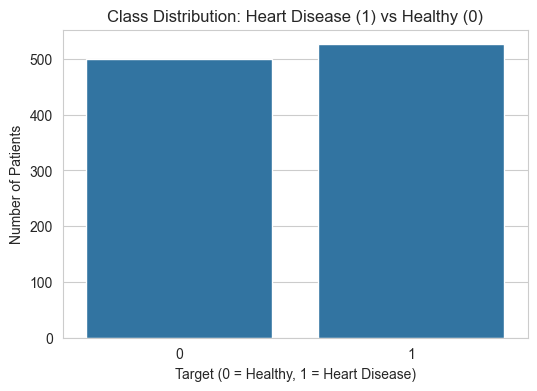

In [16]:
# Plot 1: Class balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Class Distribution: Heart Disease (1) vs Healthy (0)')
plt.xlabel('Target (0 = Healthy, 1 = Heart Disease)')
plt.ylabel('Number of Patients')
plt.show()

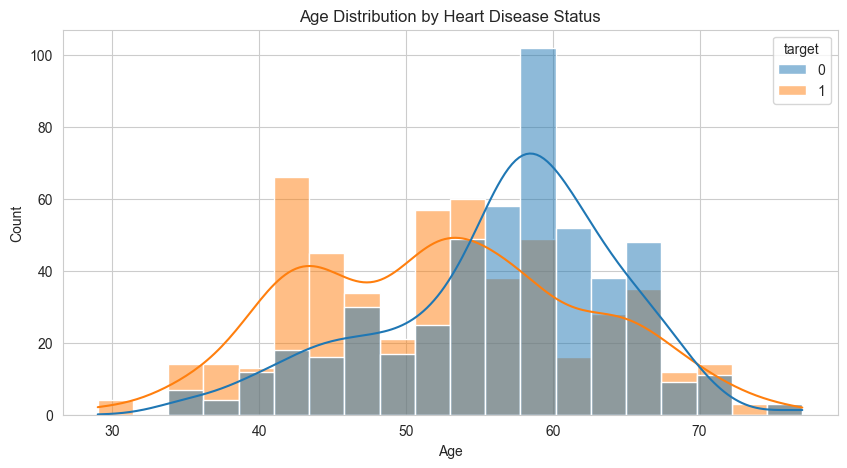

In [17]:
# Plot 2: Age distribution by heart disease status
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

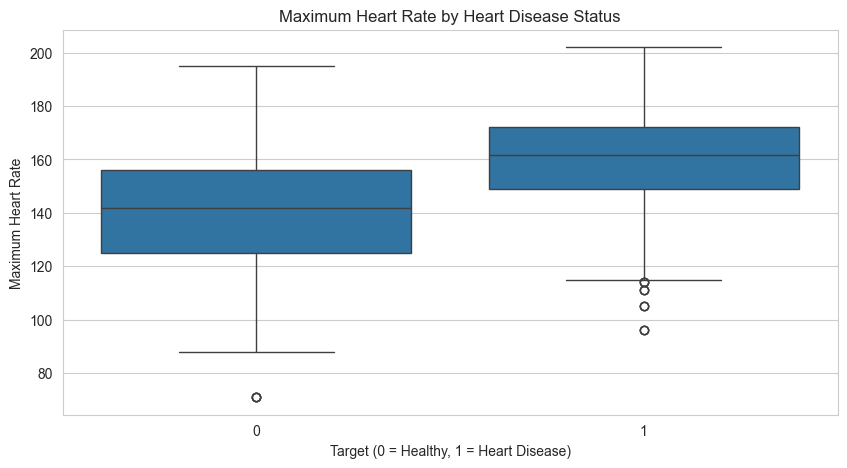

In [18]:
# Plot 3: Max heart rate vs heart disease
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='target', y='thalach')
plt.title('Maximum Heart Rate by Heart Disease Status')
plt.xlabel('Target (0 = Healthy, 1 = Heart Disease)')
plt.ylabel('Maximum Heart Rate')
plt.show()

## Preprocessing

Splitting features from target, then creating train/test sets with stratification.

In [ ]:
# Separate features (X) from target (y)
X = df.drop('target', axis=1) # all columns except target
y = df['target'] # just the target column

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", X.columns.tolist())

X shape: (1025, 13)
y shape: (1025,)

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [ ]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% for testing, 80% for training
    random_state=42, # for reproducibility
    stratify=y # preserve class balance in both sets
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:    ", X_test.shape, y_test.shape)
print("\nTrain target balance:")
print(y_train.value_counts(normalize=True))
print("\nTest target balance:")
print(y_test.value_counts(normalize=True))

Training set: (820, 13) (820,)
Test set:     (205, 13) (205,)

Train target balance:
target
1    0.513415
0    0.486585
Name: proportion, dtype: float64

Test target balance:
target
1    0.512195
0    0.487805
Name: proportion, dtype: float64


In [21]:
# Scale the features so all are on the same range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("\nMean of scaled training data (should be ~0):")
print(X_train_scaled.mean(axis=0).round(2))
print("\nStd of scaled training data (should be ~1):")
print(X_train_scaled.std(axis=0).round(2))

Scaling complete.

Mean of scaled training data (should be ~0):
[-0.  0.  0.  0. -0. -0. -0.  0. -0.  0. -0.  0. -0.]

Std of scaled training data (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Model 1: Logistic Regression

Baseline classifier. Simple, fast, and highly interpretable - a strong starting point.

In [29]:
# Train logistic regression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluate
print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.8098

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



In [ ]:
# Save results to compare later
results = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'predictions': y_pred_lr
    }
}
print(f"Logistic Regression accuracy saved: {results['Logistic Regression']['accuracy']:.4f}")

Logistic Regression accuracy saved: 0.8098


## Model 2: Decision Tree

A tree-based model that splits data through yes/no decisions. More flexible than logistic regression but prone to overfitting.

In [33]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)
print("Class balance:", df['target'].value_counts(normalize=True).round(3).to_dict())

Shape after dropping duplicates: (302, 14)
Class balance: {1: 0.543, 0: 0.457}


In [34]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (241, 13) Test: (61, 13)


In [35]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (241, 13) Test: (61, 13)


In [36]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

results = {'Logistic Regression': {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'predictions': y_pred_lr
}}

Logistic Regression Results
Accuracy: 0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [40]:
# Train decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt.predict(X_test)

# Evaluate
print("Decision Tree Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Save for comparison
results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'predictions': y_pred_dt
}

Decision Tree Results
Accuracy: 0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



## Model 3: Random Forest

An ensemble of decision trees that vote on predictions. Usually outperforms a single tree by reducing overfitting.

In [41]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'predictions': y_pred_rf
}

Random Forest Results
Accuracy: 0.7541

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



## Model Comparison

Model Comparison
Logistic Regression       Accuracy: 0.8033
Decision Tree             Accuracy: 0.8033
Random Forest             Accuracy: 0.7541


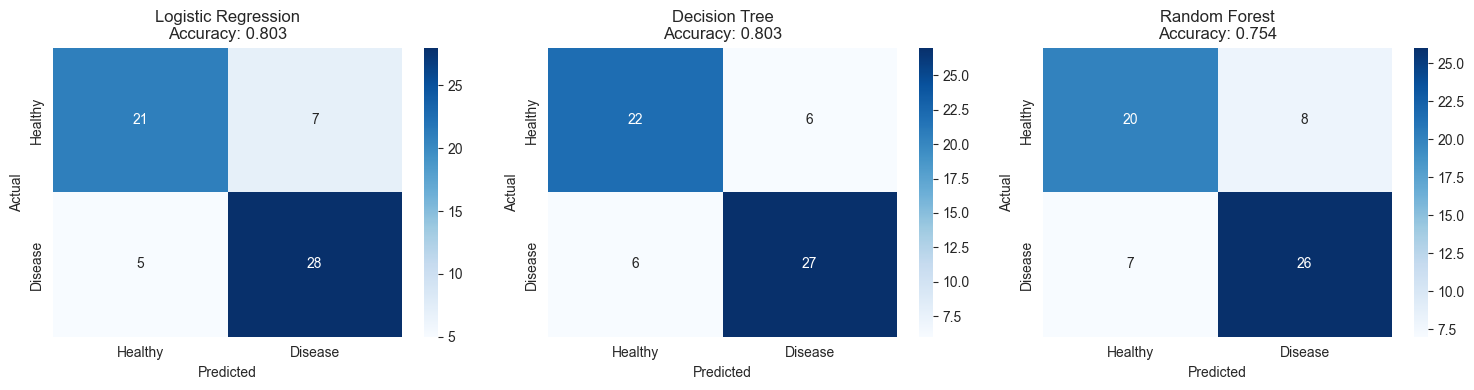

In [43]:
from sklearn.metrics import confusion_matrix

# Summary table
print("Model Comparison")
print("=" * 40)
for name, info in results.items():
    print(f"{name:25s} Accuracy: {info['accuracy']:.4f}")

# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, info) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, info['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy', 'Disease'],
                yticklabels=['Healthy', 'Disease'])
    ax.set_title(f"{name}\nAccuracy: {info['accuracy']:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Cross-Validation

Single train/test splits can be misleading. 5-fold CV gives a more trustworthy accuracy estimate.

In [44]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

print("5-Fold Cross-Validation Results")
print("=" * 50)
for name, model in models.items():
    # Use scaled data for LR, raw for trees
    X_data = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring='accuracy')
    print(f"{name:25s} {scores.mean():.4f} (+/- {scores.std():.4f})")

5-Fold Cross-Validation Results
Logistic Regression       0.8216 (+/- 0.0210)
Decision Tree             0.7263 (+/- 0.0414)
Random Forest             0.8132 (+/- 0.0300)


## Hyperparameter Tuning

Using GridSearchCV to systematically find the best logistic regression settings.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], # regularization strength
    'penalty': ['l1', 'l2'], # type of regularization
    'solver': ['liblinear'] # solver that supports both penalties
}

# Grid search with 5-fold CV
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print(f"\nTest accuracy with best parameters: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV accuracy: 0.8339

Test accuracy with best parameters: 0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Feature Importance

Which features matter most for predicting heart disease?

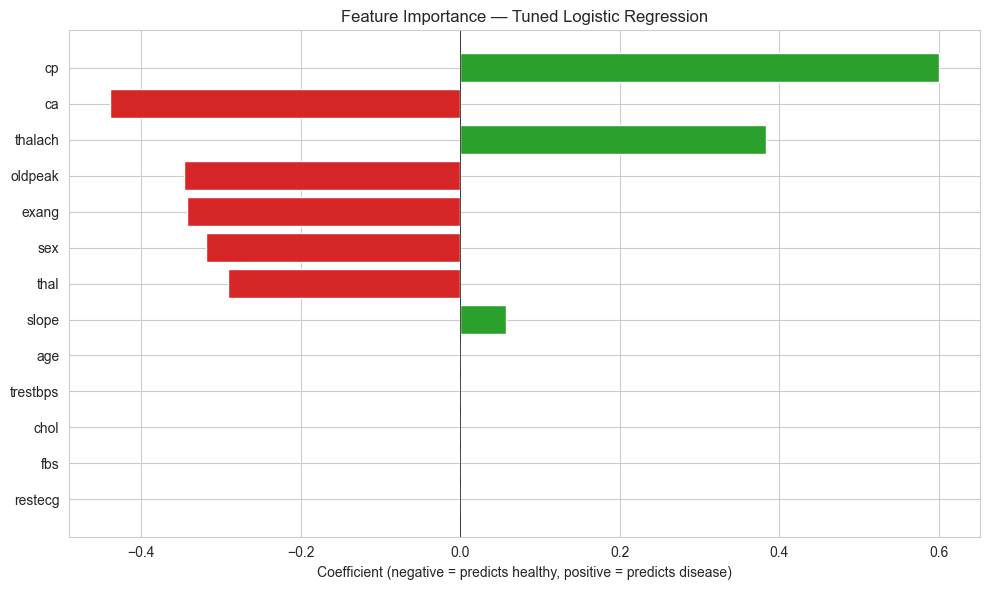


Top features by magnitude:
Feature  Coefficient
     cp     0.599913
     ca    -0.438591
thalach     0.383690
oldpeak    -0.346142
  exang    -0.343139
    sex    -0.319069
   thal    -0.290483


In [46]:
# Get coefficients from the tuned logistic regression model
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
})

# Sort by absolute value (magnitude of importance, regardless of sign)
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.xlabel('Coefficient (negative = predicts healthy, positive = predicts disease)')
plt.title('Feature Importance — Tuned Logistic Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop features by magnitude:")
print(coefficients[['Feature', 'Coefficient']].head(7).to_string(index=False))